In [16]:
import sys
!{sys.executable} -m pip install yfinance

In [19]:
import yfinance as yf
print("works")

works


In [18]:
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")

# Price chart
plt.figure(figsize=(12,6))
plt.plot(data["Close"], color="#2E86C1", linewidth=2)
plt.title("Apple Stock Price", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.grid(alpha=0.3)
plt.show()

# Returns chart
plt.figure(figsize=(12,6))
plt.plot(data["Returns"], color="#E74C3C", linewidth=1)
plt.title("Apple Daily Returns", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Returns")
plt.grid(alpha=0.3)
plt.show()

NameError: name 'data' is not defined

<Figure size 1200x600 with 0 Axes>

[*********************100%***********************]  1 of 1 completed


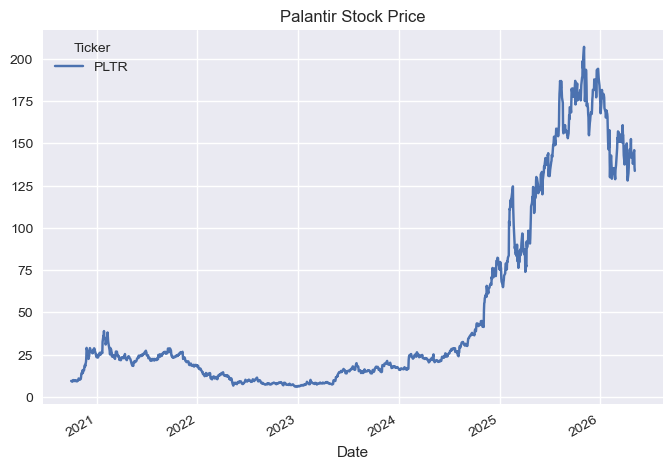

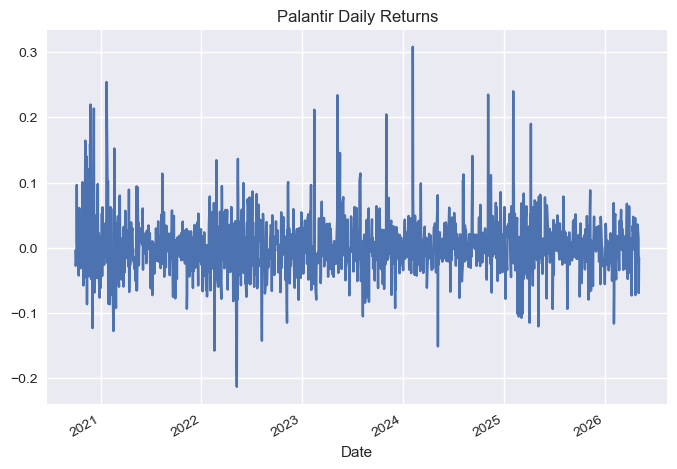

In [21]:
data = yf.download("PLTR", start="2020-01-01")

data["Returns"] = data["Close"].pct_change()

data["Close"].plot(title="Palantir Stock Price")
plt.show()

data["Returns"].plot(title="Palantir Daily Returns")
plt.show()

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Pick your portfolio stocks
tickers = ["AAPL", "MSFT", "PLTR", "NVDA", "JPM"]

# Equal weights
weights = np.array([0.20, 0.20, 0.20, 0.20, 0.20])

# Download real market data
data = yf.download(tickers, start="2020-01-01")["Close"]

# Daily returns
returns = data.pct_change().dropna()

# Portfolio daily return
portfolio_returns = returns.dot(weights)

# Annualized volatility
stock_volatility = returns.std() * np.sqrt(252)
portfolio_volatility = portfolio_returns.std() * np.sqrt(252)

print("Individual Stock Annualized Volatility:")
print(stock_volatility)

print("\nPortfolio Annualized Volatility:")
print(portfolio_volatility)

# Normalize prices to compare performance
normalized = data / data.iloc[0]

normalized.plot(figsize=(12,6), title="Stock Performance Comparison")
plt.ylabel("Growth of $1")
plt.grid(True)
plt.show()

portfolio_growth = (1 + portfolio_returns).cumprod()

portfolio_growth.plot(figsize=(12,6), title="Portfolio Growth")
plt.ylabel("Growth of $1")
plt.grid(True)
plt.show()

In [ ]:
tickers = ["AAPL","MSFT","NVDA","JPM","PLTR","SPY","QQQ","VXUS","BND"]

weights = np.array([
    0.10,  # AAPL
    0.10,  # MSFT
    0.10,  # NVDA
    0.10,  # JPM
    0.10,  # PLTR
    0.15,  # SPY
    0.10,  # QQQ
    0.10,  # VXUS
    0.05   # BND
])

In [ ]:
# Download data
data = yf.download(tickers, start="2020-01-01")["Close"]

# Calculate returns
returns = data.pct_change().dropna()

# Portfolio return
portfolio_returns = returns.dot(weights)

# Volatility
stock_volatility = returns.std() * np.sqrt(252)
portfolio_volatility = portfolio_returns.std() * np.sqrt(252)

print("Stock Volatility:")
print(stock_volatility)

print("\nPortfolio Volatility:")
print(portfolio_volatility)

# Plot comparison
normalized = data / data.iloc[0]

normalized.plot(figsize=(12,6), title="Stock Performance")
plt.show()

# Portfolio growth
portfolio_growth = (1 + portfolio_returns).cumprod()

portfolio_growth.plot(figsize=(12,6), title="Portfolio Growth")
plt.show()

In [ ]:
# Risk-free rate (approx)
rf = 0.02

# Annual return
portfolio_return_annual = portfolio_returns.mean() * 252

# Sharpe Ratio
sharpe_ratio = (portfolio_return_annual - rf) / portfolio_volatility

print("\nPortfolio Annual Return:")
print(portfolio_return_annual)

print("\nSharpe Ratio:")
print(sharpe_ratio)

In [ ]:
weights = np.array([0.1,0.1,0.1,0.1,0.1,0.15,0.1,0.1,0.05])
weights = weights / weights.sum()

In [ ]:
import numpy as np

num_portfolios = 5000

results = []

for _ in range(num_portfolios):
    random_weights = np.random.random(len(tickers))
    random_weights /= random_weights.sum()
    
    port_return = (returns.mean() * random_weights).sum() * 252
    port_vol = np.sqrt(np.dot(random_weights.T, np.dot(returns.cov() * 252, random_weights)))
    sharpe = (port_return - 0.02) / port_vol
    
    results.append([port_return, port_vol, sharpe, random_weights])

# Convert to DataFrame
results_df = pd.DataFrame(results, columns=["Return", "Volatility", "Sharpe", "Weights"])

# Best portfolio
best = results_df.iloc[results_df["Sharpe"].idxmax()]

print("Best Portfolio:")
print("Return:", best["Return"])
print("Volatility:", best["Volatility"])
print("Sharpe:", best["Sharpe"])
print("Weights:", best["Weights"])

In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(results_df["Volatility"], results_df["Return"], c=results_df["Sharpe"], cmap="viridis")
plt.colorbar(label="Sharpe Ratio")
plt.xlabel("Volatility")
plt.ylabel("Return")
plt.title("Portfolio Optimization")
plt.show()

In [22]:
# Risk Metrics Section

import numpy as np

# Use your existing portfolio daily returns here
# If your variable is named differently, tell me the exact name.
portfolio_returns = data["Returns"]

cumulative_return = (1 + portfolio_returns).prod() - 1
volatility = portfolio_returns.std() * np.sqrt(252)
sharpe_ratio = (portfolio_returns.mean() * 252) / volatility

cumulative_growth = (1 + portfolio_returns).cumprod()
running_max = cumulative_growth.cummax()
drawdown = (cumulative_growth - running_max) / running_max
max_drawdown = drawdown.min()

print("Cumulative Return:", round(cumulative_return, 4))
print("Annualized Volatility:", round(volatility, 4))
print("Sharpe Ratio:", round(sharpe_ratio, 4))
print("Max Drawdown:", round(max_drawdown, 4))

Cumulative Return: 13.0832
Annualized Volatility: 0.6998
Sharpe Ratio: 1.0195
Max Drawdown: -0.8462


In [ ]:
%whos

In [ ]:
%whos

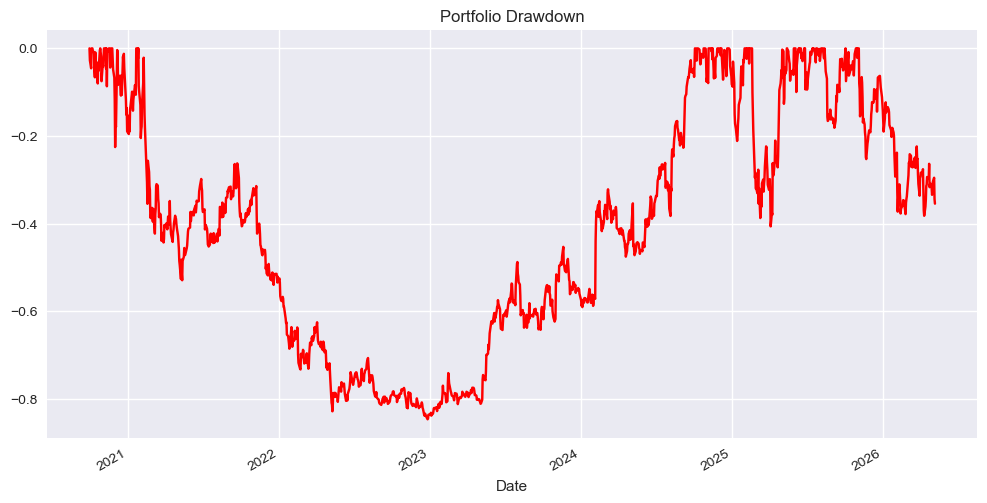

In [23]:
drawdown.plot(title="Portfolio Drawdown", figsize=(12,6), color="red")
plt.show()

[*********************100%***********************]  1 of 1 completed


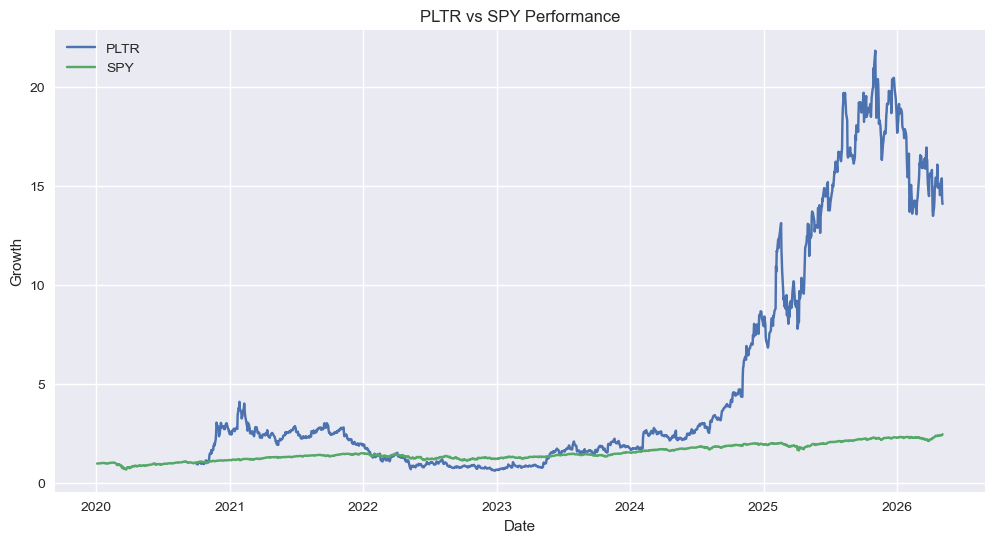

In [24]:
spy = yf.download("SPY", start="2020-01-01")

spy["Returns"] = spy["Close"].pct_change()

portfolio_growth = (1 + data["Returns"]).cumprod()
spy_growth = (1 + spy["Returns"]).cumprod()

plt.figure(figsize=(12,6))

plt.plot(portfolio_growth, label="PLTR")
plt.plot(spy_growth, label="SPY")

plt.title("PLTR vs SPY Performance")
plt.xlabel("Date")
plt.ylabel("Growth")

plt.legend()

plt.show()

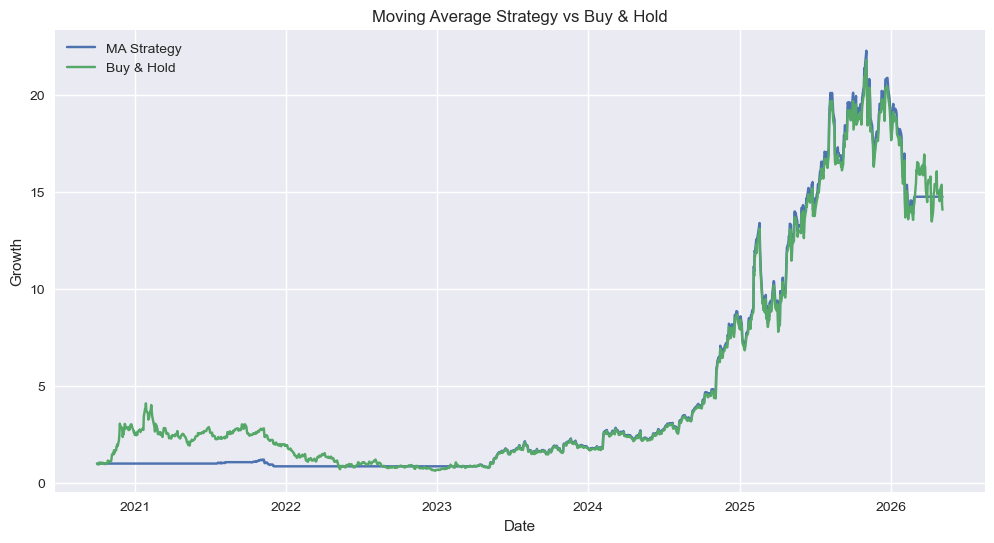

In [25]:
# Moving Average Strategy Backtest

data["MA50"] = data["Close"].rolling(window=50).mean()
data["MA200"] = data["Close"].rolling(window=200).mean()

data["Signal"] = 0
data.loc[data["MA50"] > data["MA200"], "Signal"] = 1

data["Strategy_Returns"] = data["Signal"].shift(1) * data["Returns"]

strategy_growth = (1 + data["Strategy_Returns"]).cumprod()
buy_hold_growth = (1 + data["Returns"]).cumprod()

plt.figure(figsize=(12,6))
plt.plot(strategy_growth, label="MA Strategy")
plt.plot(buy_hold_growth, label="Buy & Hold")
plt.title("Moving Average Strategy vs Buy & Hold")
plt.xlabel("Date")
plt.ylabel("Growth")
plt.legend()
plt.show()

In [26]:
strategy_volatility = data["Strategy_Returns"].std() * np.sqrt(252)

strategy_sharpe = (
    data["Strategy_Returns"].mean() * 252
) / strategy_volatility

print("Strategy Volatility:", round(strategy_volatility, 4))
print("Strategy Sharpe Ratio:", round(strategy_sharpe, 4))

Strategy Volatility: 0.4842
Strategy Sharpe Ratio: 1.2317
